### 당뇨 데이터 딥러닝으로 분류
202435119 한여원

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"D:\hanyeowon\Coding\pythonworks\deep\data\diabetes.csv")
df = df.drop("Outcome", axis=1)


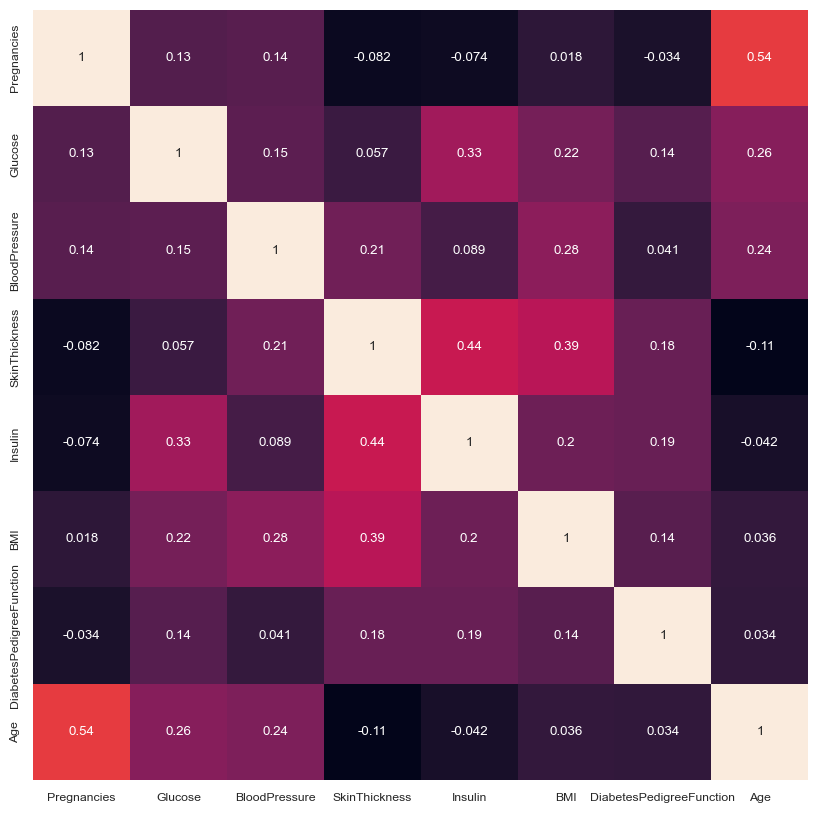

In [5]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [ ]:
y = df["BMI"]
X = df.drop("BMI", axis=1)
X = X.values

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

0      33.6
1      26.6
2      23.3
3      28.1
4      43.1
       ... 
763    32.9
764    36.8
765    26.2
766    30.1
767    30.4
Name: BMI, Length: 768, dtype: float64


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # 모든 값들을 표준정규분포 형태로 변환
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 모델 정의
model = models.Sequential([
    layers.Dense(164, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.1),
    layers.Dense(164, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 953.6563 - mse: 953.6563 - val_loss: 728.7346 - val_mse: 728.7346
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 474.1759 - mse: 474.1759 - val_loss: 218.8809 - val_mse: 218.8809
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 130.4140 - mse: 130.4140 - val_loss: 104.8783 - val_mse: 104.8783
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89.5201 - mse: 89.5201 - val_loss: 81.8918 - val_mse: 81.8918
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 79.7947 - mse: 79.7947 - val_loss: 80.1301 - val_mse: 80.1301
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 73.3963 - mse: 73.3963 - val_loss: 76.0476 - val_mse: 76.0476
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70.6838 - mse: 70.6838 - val_loss: 74.4096 - val_mse: 74.4096
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 65.2892 - mse: 65.2892 - val_loss: 71.9562 - val_mse: 71.9562
Epoch 9/50
29/29 ━━━━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


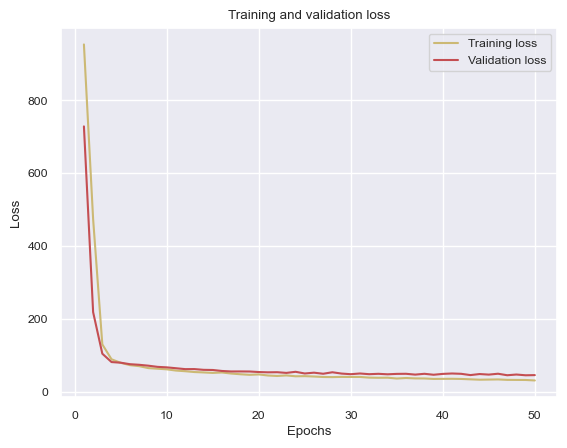

In [9]:
y_pred = model.predict(X_test_scaled)

loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
print(loss)
print(val_loss)
print(mse)
print(val_mse)
print(y_test.shape)
print(y_pred.shape)
print(y_test)
print(y_pred)

[953.6563110351562, 474.1759033203125, 130.41404724121094, 89.52012634277344, 79.7947006225586, 73.39634704589844, 70.68384552001953, 65.2891845703125, 63.64174270629883, 61.968421936035156, 58.54247283935547, 56.78676986694336, 54.50705337524414, 53.426509857177734, 52.13923263549805, 53.29207992553711, 50.38539123535156, 48.43037033081055, 46.87419891357422, 47.92924499511719, 44.99091339111328, 43.704139709472656, 45.215370178222656, 42.86289596557617, 43.2264404296875, 42.21830749511719, 40.89210510253906, 40.603187561035156, 41.136871337890625, 40.98238754272461, 41.04212951660156, 39.17758560180664, 38.740150451660156, 39.01276397705078, 36.69585418701172, 38.15191650390625, 37.04666519165039, 36.87013244628906, 35.5749397277832, 35.80963897705078, 35.981300354003906, 35.54607009887695, 34.520267486572266, 33.480438232421875, 33.84849548339844, 34.23912048339844, 33.044334411621094, 32.89265441894531, 32.71928405761719, 31.423583984375]
[728.734619140625, 218.8809051513672, 104.8

In [ ]:
from sklearn.metrics import r2_score
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.23255471916092418
